## Social Media Effect on Teens

Exploratory Data Analysis Notes: 

- Large class imbalance in the target variable > Consider using oversampling techniques (SMOTE)

In [2]:
import os
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
raw_data_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'Teen_Mental_Health_Dataset.csv')

raw_df = pd.read_csv(raw_data_path)

raw_df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [4]:
# Shape and Data Types 
print(raw_df.shape) 
print(raw_df.info())

(1200, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB
None


In [5]:
print(f"Missing values dataframe:\n{raw_df.isnull().sum()}")

Missing values dataframe:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [6]:
# Summary Statistics 
raw_df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


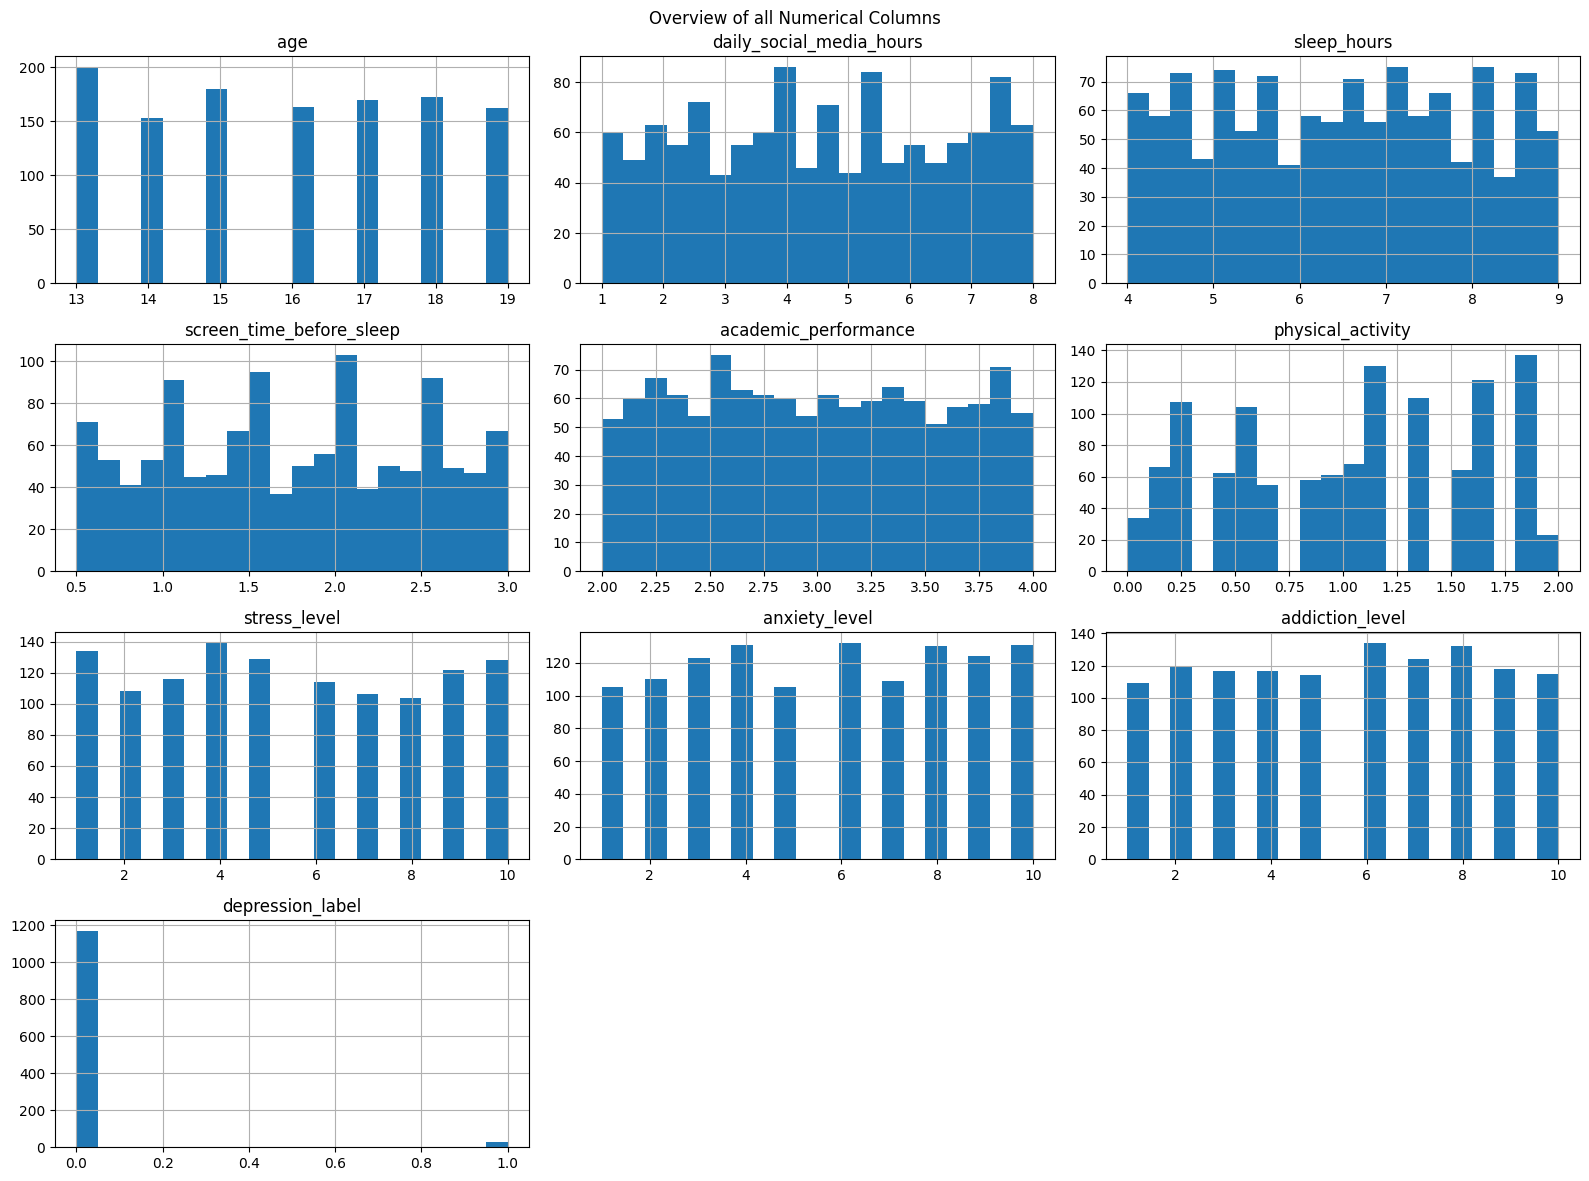

In [7]:
raw_df.hist(figsize=(16,12), bins = 20) 

plt.suptitle("Overview of all Numerical Columns")
plt.tight_layout()
plt.show()

/var/folders/tm/zd2ldwcj6w5cml9j9n1_pcsr0000gn/T/ipykernel_14876/3287520061.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = raw_df.select_dtypes(include = 'object').columns


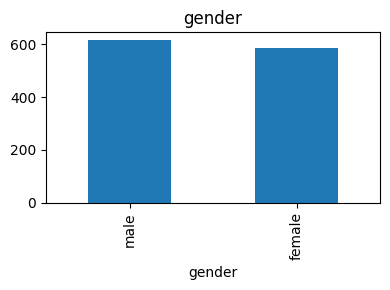

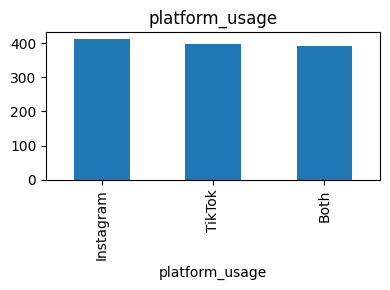

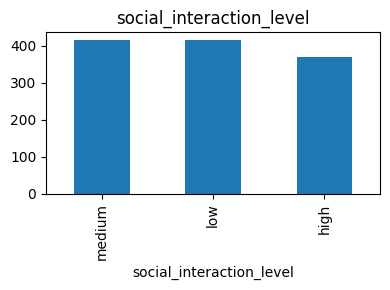

In [8]:
# Check categorical columns 
cat_cols = raw_df.select_dtypes(include = 'object').columns

for col in cat_cols: 
    raw_df[col].value_counts().plot(kind = 'bar', title = col, figsize = (4,3))
    plt.tight_layout()
    plt.show()

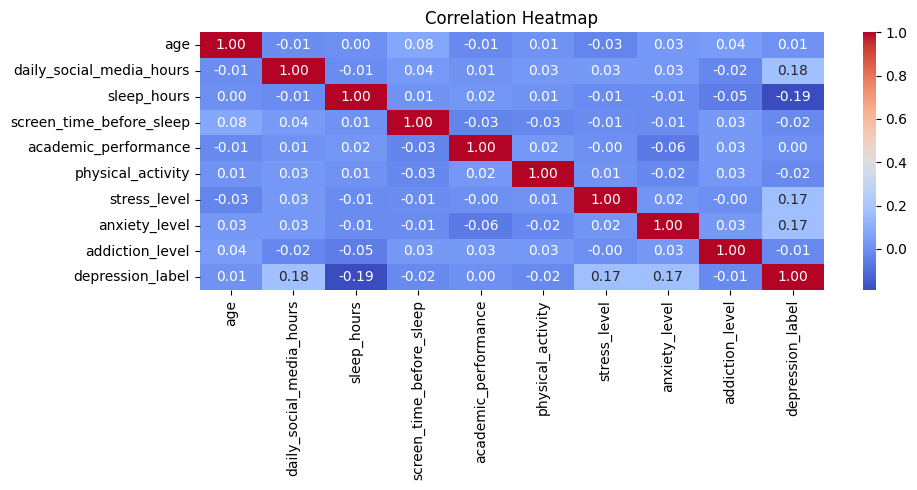

In [9]:
# Correlation heatmap 
plt.figure(figsize = (10,5)) 
sns.heatmap(raw_df.select_dtypes(include = 'number').corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

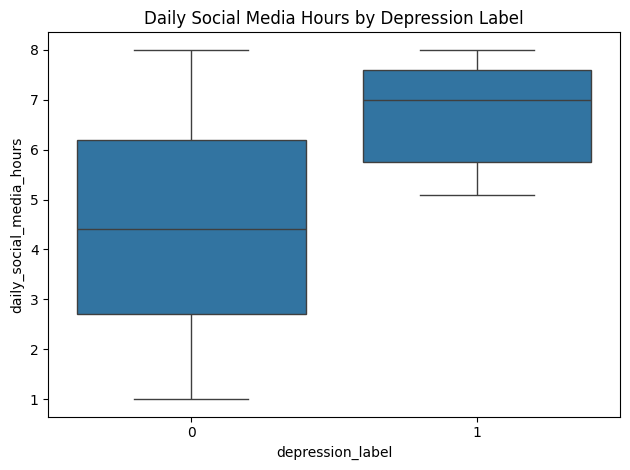

In [10]:
# Check social media hours and depression label 
sns.boxplot(x = 'depression_label', y = 'daily_social_media_hours', data = raw_df)
plt.title('Daily Social Media Hours by Depression Label')
plt.tight_layout()
plt.show()

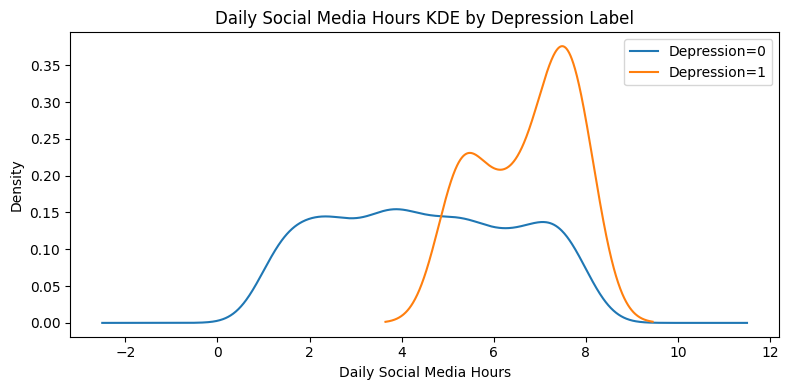

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, group in raw_df.groupby('depression_label'):
    group['daily_social_media_hours'].plot(kind='kde', ax=ax, label=f'Depression={label}')

ax.set_title('Daily Social Media Hours KDE by Depression Label')
ax.set_xlabel('Daily Social Media Hours')
ax.legend()
plt.tight_layout()
plt.show()


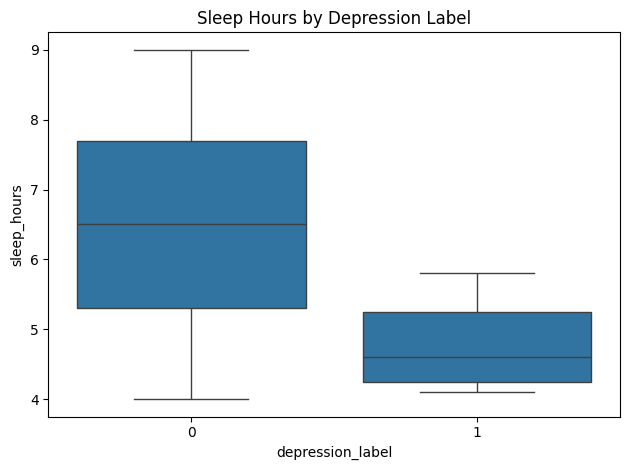

In [11]:
# Sleep 
sns.boxplot(x = 'depression_label', y = 'sleep_hours', data = raw_df)
plt.title('Sleep Hours by Depression Label')
plt.tight_layout()
plt.show()

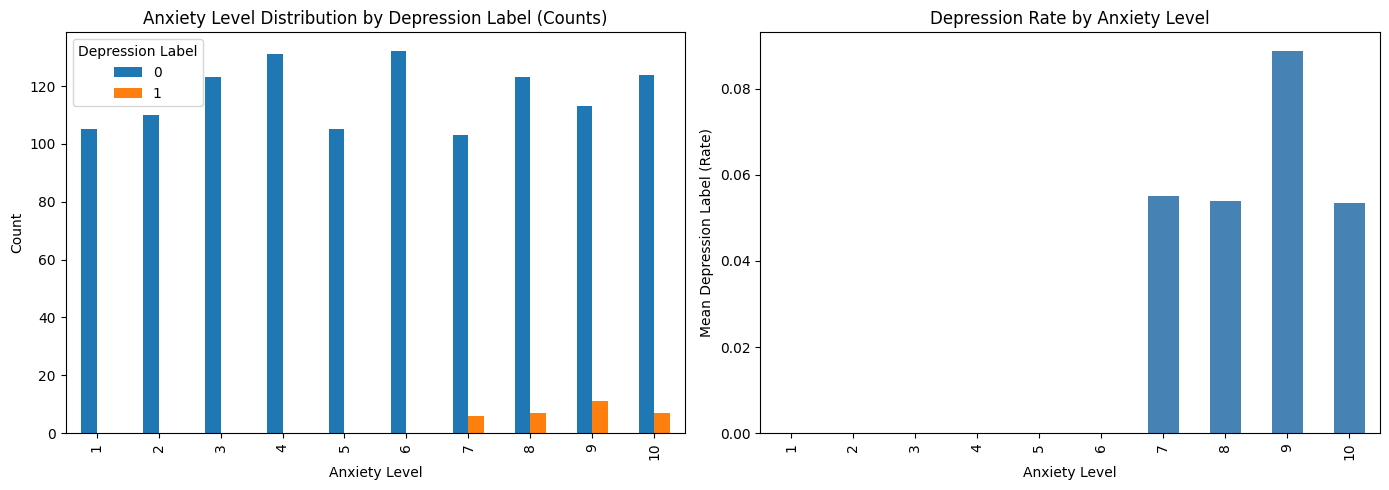

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts - affected by class imbalance
anxiety_counts = raw_df.groupby(['depression_label', 'anxiety_level']).size().unstack(level=0)
anxiety_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Anxiety Level Distribution by Depression Label (Counts)')
axes[0].set_xlabel('Anxiety Level')
axes[0].set_ylabel('Count')
axes[0].legend(title='Depression Label')

# Depression rate per anxiety level - normalizes for class imbalance
raw_df.groupby('anxiety_level')['depression_label'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Depression Rate by Anxiety Level')
axes[1].set_xlabel('Anxiety Level')
axes[1].set_ylabel('Mean Depression Label (Rate)')

plt.tight_layout()
plt.show()

Anxiety level appears to be a strong predictor of depression. After normalizing for class imbalance (depression rate per anxiety level), zero depressed cases exist below anxiety level 7. This suggests a near-hard decision boundary around anxiety level 7, making this a potentially powerful feature for the model. SMOTE will only synthesize minority class samples in the high-anxiety region (7–10), which is appropriate given no real depressed low-anxiety cases exist.

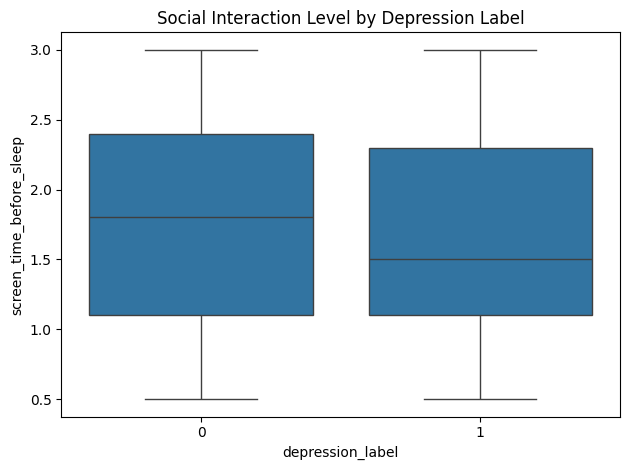

In [13]:
# Check screen_time_before_sleep and depression 
sns.boxplot(x = 'depression_label', y = 'screen_time_before_sleep', data = raw_df)
plt.title('Social Interaction Level by Depression Label')
plt.tight_layout()
plt.show()

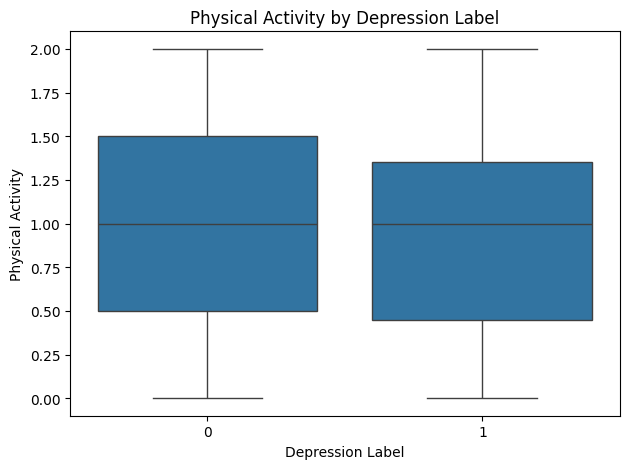

In [17]:
# Check physical_activity and depression 
sns.boxplot(x = 'depression_label', y = 'physical_activity', data = raw_df)
plt.title('Physical Activity by Depression Label')
plt.tight_layout()
plt.xlabel('Depression Label')
plt.ylabel('Physical Activity')
plt.show()

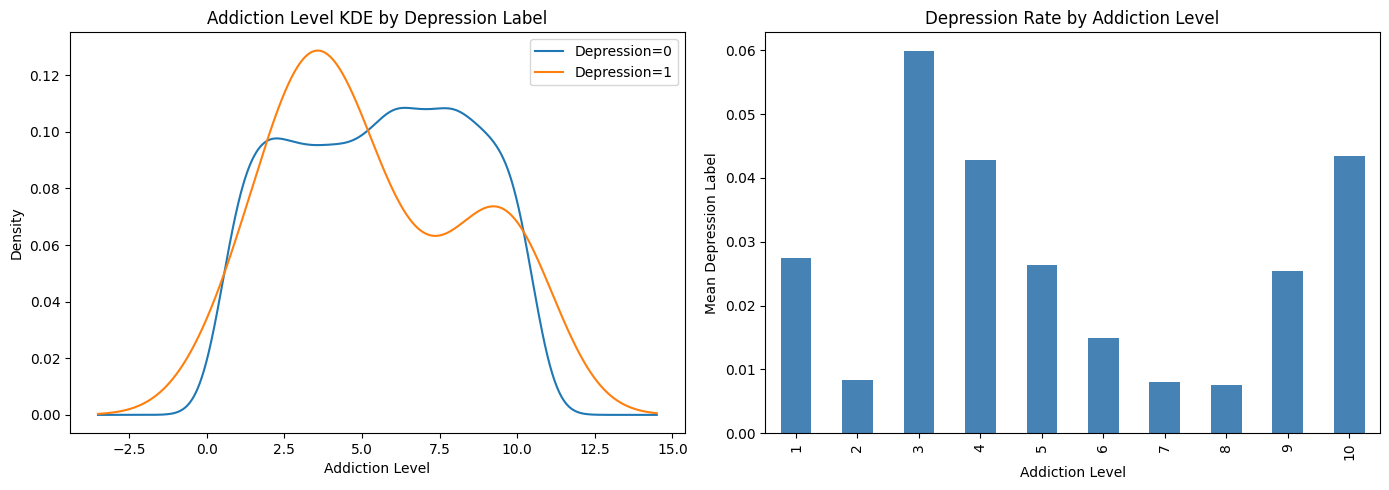

In [15]:
## Plot Addiction Level and Depression Label 
# Conceptually, these should be strongly linked but we see a correlation of -0.01 showing that the two points could be highly non-linear 

fig, axes = plt.subplots(1,2, figsize = (14,5)) 

# KDE plot - shows distribution shape and overlap
for label, group in raw_df.groupby('depression_label'):
    group['addiction_level'].plot(kind='kde', ax=axes[0], label=f'Depression={label}')
axes[0].set_title('Addiction Level KDE by Depression Label')
axes[0].set_xlabel('Addiction Level')
axes[0].legend()

# Mean addiction level per value - reveals nonlinear patterns
raw_df.groupby('addiction_level')['depression_label'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Depression Rate by Addiction Level')
axes[1].set_xlabel('Addiction Level')
axes[1].set_ylabel('Mean Depression Label')

plt.tight_layout()
plt.show()

Addiction level doesn't move with depression rates, so this could just be noise. This could confirm that `addiction_level` as it's currently encoded will not be useful feature unless it is engineerred. Could possible bin these into a variable with lower cardinality. 